# Superstore Retail Analytics — Cleaning and Exploration
### Sales, Profitability, Customer Behavior & Operational Performance
**Business Scenario:** A multinational retail company needs an automated analytical
solution to monitor sales, profitability, customer behavior, and operational
performance from its transactional data.

**Workflow:**
1. Data Import & Inspection
2. Memory Optimization and Fixing Types
3. Advanced Data Cleaning (reusable pipeline)
5. Export of Cleaned Data


---
This notebook walks through the **cleaning and exploration phase** only 
the feature-engineering, visualization and reporting layers live in a separate notebook.
The goal here is to take the raw Superstore export and turn it into a
trustworthy, analysis-ready `df_cleaned` DataFrame, one deliberate step at a
time, with every decision explained as we go.

## 1. Data Import & Inspection
#### What is the data that we will handle with it ?

We first need to *see* the data before touching it: how many rows/columns,
what types pandas inferred, whether anything looks obviously wrong (nulls,
duplicate order lines, inconsistent text). Only after this inspection pass do
we move on to fixing anything.

### A. Import the Laibraries and Dataset

**Loading the data.**
`pd.read_csv` reads the raw export with the first column (`Row ID`) used as
the DataFrame index. Right after loading, we also write an untouched Parquet
copy of the raw file (`Sample-Superstore2019.parquet`) — Parquet preserves
dtypes and is far faster to re-read than CSV, so it's a useful checkpoint even
before any cleaning happens.

In [78]:
# Core libraries for cleaning and exploring data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import pyarrow
import seaborn as sns

# Read the CSV into a DataFrame.
df_raw = pd.read_csv("Sample-Superstore2019.csv", index_col=0 )

df_raw.to_parquet("Sample-Superstore2019.parquet")

**Never mutate the original load.**
`df = df_raw.copy()` gives us a working copy so that `df_raw` always stays
available as an unmodified fallback if we need to compare against the
original or start a cleaning step over.

In [5]:
#copy the data frame to a new variable to avoid changing the original data frame
df = df_raw.copy()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### B. Inspect and Describe The Data

**Shape and a quick visual sanity check.**
`.shape` tells us row/column count at a glance. Looking at `.tail(3)` (rather
than only `.head()`) helps catch issues that only show up later in the file,
such as a different formatting convention appearing near the end of an export.

In [6]:
# Shape: (number of rows, number of columns)
print("Shape:", df.shape)

# last rows — sanity check that data looks like what we expect
df.tail(3)

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


**Column names.**
Printing the raw column list confirms exact spelling/casing (e.g. `Ship Mode`
vs `ShipMode`) before we reference these names anywhere else in the notebook —
a mismatch here is one of the most common sources of `KeyError`s downstream.
`Categorical_columns` is initialized here as an empty list and gets populated
properly later in Section 3C.

In [7]:
# Column names
print(f"Column names: {df.columns.tolist()}")
Categorical_columns = []

Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**`.info()` — the fastest first checkpoint.**
This single call reports, for every column: its inferred dtype, how many
non-null values it has (so missing data is visible immediately), and total
memory footprint. It's the cheapest way to get an overview of *both* data
quality and data cost in one shot.

In [8]:
# .info() gives dtypes + non-null counts + memory usage all at once
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   str    
 2   Order Date      9994 non-null   str    
 3   Ship Date       9994 non-null   str    
 4   Ship Mode       9994 non-null   str    
 5   Customer ID     9994 non-null   str    
 6   Customer Name   9994 non-null   str    
 7   Segment         9994 non-null   str    
 8   Country/Region  9994 non-null   str    
 9   City            9994 non-null   str    
 10  State           9994 non-null   str    
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   str    
 13  Product ID      9994 non-null   str    
 14  Category        9994 non-null   str    
 15  Sub-Category    9994 non-null   str    
 16  Product Name    9994 non-null   str    
 17  Sales           9994 non-null   float64
 18 

**Numeric summary statistics.**
`.describe()` reports count, mean, std, min, quartiles, and max for every
numeric column. Watch in particular for:
- `Profit` having a **negative minimum** — orders sold at a loss (expected,
  not an error, in retail data).
- `Discount` bounded between 0 and 1 — anything outside that range would flag
  a data-entry problem.
- `Postal Code` showing up here even though it's really a categorical/ID
  field, not a quantity — a sign it should be cast to `str`, which we do in
  Section 2B.

In [9]:
# Summary stats for numeric columns: Sales, Quantity, Discount, Profit, Postal Code, Row ID...
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**Categorical/text summary statistics.**
`describe(include="str")` mirrors the same idea for text columns: count,
number of unique values, the most frequent value, and its frequency. This is
a fast way to eyeball cardinality (e.g. how many distinct `Customer Name`
values exist) and to catch a dominant category before doing any grouping.

In [10]:
# Summary stats for text/categorical columns
df.describe(include="str")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1236,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2019-100111,2018-09-05,2017-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


## 2. Memory Optimization
#### What the cost of storing this data and How to reduce this cost?

Before optimizing anything, we need a baseline: how much memory does the
DataFrame actually consume *right now*, column by column? Without this
number, "we reduced memory usage" has nothing to be measured against.

### A. Discover Memory

**`memory_usage(deep=True)` — why `deep=True` matters.**
For object/string columns, pandas stores pointers, not raw bytes, so a
shallow memory count is misleading. `deep=True` walks into the actual string
data and reports true memory consumption per column — this is the number we
compare against after the dtype fixes below.

In [12]:
df.memory_usage(deep=True)

Index                132
Row ID             79952
Order ID          219868
Order Date        179892
Ship Date         179892
Ship Mode         208106
Customer ID       159904
Customer Name     209570
Segment           168273
Country/Region    209874
City              173203
State             164773
Postal Code        79952
Region            128517
Product ID        229862
Category          207901
Sub-Category      151826
Product Name      449496
Sales              79952
Quantity           79952
Discount           79952
Profit             79952
dtype: int64

### B. Fix The Datatypes 

**Fixing dtypes: dates and postal codes.**
Two separate problems are being solved here:
- `Order Date` / `Ship Date` arrive as plain text; `pd.to_datetime` converts
  them to real `datetime64[ns]` values, which is what makes date arithmetic
  (e.g. shipping duration), `.dt` accessors, and time-based grouping possible
  later.
- `Postal Code` arrives as a *float* (because of the missing values pandas
  saw on load), which is wrong for an identifier that should never be
  averaged or summed. Casting it to `str` fixes the semantic type — though
  note this happens *before* the missing-value fix in Section 3A, so at this
  point any null postal codes are still floating around as the literal string
  `"nan"`.

In [13]:
# Convert the two date columns from text to real datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Postal Code"] = df["Postal Code"].astype("str")

# Check the dtypes of the two date columns to confirm they are now datetime64[ns]
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)
print(df["Postal Code"].dtype)

datetime64[us]
datetime64[us]
str


**Fixing dtypes: low-cardinality text → `category`.**
Columns like `Segment`, `Region`, `Ship Mode`, and `Category` only take on a
handful of distinct values across ~10,000 rows. Storing them as pandas
`category` dtype keeps one small integer code per row plus a single shared
lookup table of the distinct labels, instead of repeating the full string
on every row — the single biggest lever for memory reduction available here.

In [14]:
# Convert low-cardinality text columns to the 'category' dtype (memory + speed win)
for col in ["Segment", "Region", "Ship Mode", "Category"]:
    df[col] = df[col].astype("category")

df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region               str
City                         str
State                        str
Postal Code                  str
Region                  category
Product ID                   str
Category                category
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

Now that the date columns and the low-cardinality text columns have been
re-typed, we re-run the same memory check from Section 2A to confirm the
optimization actually worked, rather than just assuming it did.

### Cofirm Memory Reduction

**Confirming the reduction.**
Comparing this `df.info(memory_usage='deep')` output against the Section 2A
baseline should show a visibly smaller total memory footprint — the
`category` conversions in particular should meaningfully shrink `Segment`,
`Region`, `Ship Mode`, and `Category`.

In [15]:
print(df.info(memory_usage='deep'))

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   category      
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   category      
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   str           
 12  Region          9994 non-null   category      
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   category      
 15  Sub-Category   

## 3. Data Cleaning
### Is any data missing or duplicated or dirty and how to clean it ?

**Strategy: locate, understand, then decide.**
For every column with missing data we want to know *how many* values are
missing and *why*, before picking a fix — dropping rows is not always the
right call, and a blind fill can hide a real data problem.

### A. Detect Missing Data and Handle With IT

**Counting nulls per column.**
`isnull().sum()` gives the missing-value count column by column. In this
dataset, `Postal Code` is the only column with nulls — everything else is
fully populated.

In [16]:
# Count missing values per column
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

**Investigating the missing `Postal Code` values.**
Rather than filling blindly, we look at the actual `City`/`State` for the
affected rows. If the missing postal codes cluster around one specific
city, that's a strong signal for what value should be imputed, instead of a
generic placeholder or an outright drop.

In [17]:
# Look at the actual rows with a missing Postal Code — is there a pattern?
df[df["Postal Code"].isnull()][["City", "State", "Postal Code"]]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


**Imputing the missing `Postal Code`.**
Based on the city/state pattern observed above, the missing values are filled
with `"05401"` — a real, specific postal code rather than an arbitrary
sentinel — and `df_cleaned` is created here as the working copy that all
later cleaning steps (duplicates, dirty text, outliers) build on top of.

In [18]:
df["Postal Code"] = df["Postal Code"].fillna("05401")
df_cleaned = df.copy()
# Confirm there are no missing values left in this column
df_cleaned["Postal Code"].isnull().sum()

np.int64(0)

Missing values are handled — next we check whether any row (or any
meaningful subset of columns) is repeated when it shouldn't be, since
duplicate order lines would silently inflate every sales and profit total
computed later.

### B. Detect Duplicates and remove it

**Two different duplicate checks.**
- `duplicated()` with no arguments checks for **exact, full-row** duplicates
  — every single column matching. There are none.
- `duplicated(subset=["Order ID", "Product ID"])` checks something more
  business-meaningful: the *same product appearing more than once within the
  same order*. This can be entirely legitimate (e.g. two rows for the same
  product bought on different discount terms), so it needs a closer look
  rather than an automatic drop — which is exactly what the next two cells do.

In [19]:
# Exact full-row duplicates
print("Exact duplicate rows:", df_cleaned.duplicated().sum())

# Duplicates on a more meaningful subset: same order line for the same product
print("Duplicate Order ID + Product ID pairs :", df_cleaned.duplicated(subset=["Order ID", "Product ID"]).sum())

Exact duplicate rows: 0
Duplicate Order ID + Product ID pairs : 8


**Inspecting subset-duplicates on the pre-imputation `df`.**
Pulling up the actual rows behind the `Order ID` + `Product ID` duplicate
flag (sorted so matching pairs sit next to each other) lets us confirm
whether these are true duplicate entries or legitimately separate line items
(different quantities, prices, or discounts) before deciding not to drop
them.

In [20]:
# Inspect what those subset-duplicates actually look like
dup_mask = df.duplicated(subset=["Order ID", "Product ID"], keep=False)
df[dup_mask].sort_values(["Order ID", "Product ID"]).head(8)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6498,6499,CA-2017-103135,2017-07-24,2017-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,Louisville,...,40214.0,South,OFF-BI-10000069,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",135.09,9,0.0,62.1414
6500,6501,CA-2017-103135,2017-07-24,2017-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,Louisville,...,40214.0,South,OFF-BI-10000069,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",90.06,6,0.0,41.4276
350,351,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009.0,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,24.56,2,0.0,11.5432
352,353,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009.0,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,49.12,4,0.0,23.0864
1300,1301,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153.0,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.76,6,0.0,166.1004
1301,1302,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153.0,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",286.38,3,0.0,83.0502
9168,9169,CA-2018-140571,2018-03-15,2018-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,Jackson,...,39212.0,South,OFF-PA-10001954,Office Supplies,Paper,Xerox 1964,319.76,14,0.0,147.0896
9169,9170,CA-2018-140571,2018-03-15,2018-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,Jackson,...,39212.0,South,OFF-PA-10001954,Office Supplies,Paper,Xerox 1964,45.68,2,0.0,21.0128


**Same inspection, repeated on `df_cleaned`.**
Re-running the check on `df_cleaned` (after the `Postal Code` fill) confirms
the same duplicate pattern still holds post-imputation, and that the
imputation step didn't accidentally introduce or remove any of these rows.

In [22]:
# Inspect what those subset-duplicates actually look like
dup = df_cleaned.duplicated(subset=["Order ID", "Product ID"], keep=False)
df_cleaned[dup].sort_values(["Order ID", "Product ID"]).head(8)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


"Dirty" here means *inconsistent formatting* rather than missing data:
stray whitespace, inconsistent casing, or unexpected category variants that
would cause the same real-world value to be counted as two different groups
in any `groupby()`.

### C. Detect Dirty Data and Handle with it

**Splitting columns by cardinality.**
Any column with fewer than 5 distinct values gets bucketed as
`Categorical_columns` (e.g. `Ship Mode`, `Segment`) — these are cheap to
eyeball in full. Everything else (`others`) is high-cardinality (names, IDs,
product titles) and isn't a good candidate for a full `.unique()` printout.

In [62]:
Categorical_columns = []
others = []
for col in df_cleaned.columns:
    if df_cleaned[col].nunique() < 5:
        Categorical_columns.append(col) 
    else:
        others.append(col)

print(f"Categorical columns ({len(Categorical_columns)} columns): {Categorical_columns}")
print(f"Other columns ({len(others)} columns): {others}")

Categorical columns (5 columns): ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category']
Other columns (16 columns): ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name', 'City', 'State', 'Postal Code', 'Product ID', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**Whitespace cleanup and category-value audit.**
Every object/text column gets `.str.strip()` applied to remove leading/
trailing whitespace that wouldn't be visible on a normal print but would
still split identical values into separate groups. Then, for just the
low-cardinality `Categorical_columns` identified above, we print every
distinct value that actually appears — the fast way to catch a stray
`"consumer "` vs `"Consumer"`-style inconsistency.

In [105]:
# Check every key categorical column for stray variants (casing, whitespace, typos)
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip()

    
for col in Categorical_columns:
    print(col, "->", df_cleaned[col].unique())

Ship Mode -> ['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, str): ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Segment -> <ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Country/Region -> <ArrowStringArray>
['United States']
Length: 1, dtype: str
Region -> ['South', 'West', 'Central', 'East']
Categories (4, str): ['Central', 'East', 'South', 'West']
Category -> ['Furniture', 'Office Supplies', 'Technology']
Categories (3, str): ['Furniture', 'Office Supplies', 'Technology']


C:\Users\MZ\AppData\Local\Temp\ipykernel_4008\2081630390.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns


Outliers get a different treatment from missing/duplicate data: an extreme
`Sales` or `Profit` value isn't necessarily *wrong* — a single bulk order or
a heavily discounted loss-leader is a real business event. The goal here is
to **detect and understand** extreme values, not to blindly strip them out.

### D. Detect Outliers and Handle With It.

**Range sanity checks first.**
Before running any statistical outlier detection, two quick domain checks:
`Discount` should always fall within `[0, 1]` (it does), and negative
`Profit` values are counted — these are expected in retail data (heavily
discounted or bulk orders can sell at a loss) rather than a sign of corrupted
data.

In [26]:
# Range sanity check: Discount should never be negative or above 1 (100%)
print("Discount min/max:", df_cleaned["Discount"].min(), df_cleaned["Discount"].max())

# Negative profit is common in this dataset -- a real business signal, not an error
print("Orders sold at a loss:", (df_cleaned["Profit"] < 0).sum())

Discount min/max: 0.0 0.8
Orders sold at a loss: 1870


**Average Sales per Segment.**
Grouping by `Segment` and taking the mean `Sales` gives a first look at
whether outlier behavior might differ meaningfully across segments before we
split the data three ways in the next cell.

In [72]:
# Segment Sales by Segment
segment_sales = df_cleaned.groupby("Segment")["Sales"].mean()
print(segment_sales)

Segment
Consumer       223.744966
Corporate      233.720433
Home Office    241.223260
Name: Sales, dtype: float64


**Splitting the data by segment.**
`Consumer_Sales`, `Corporate_Sales`, and `Home_Office_Sales` isolate each
`Segment` into its own DataFrame slice, so outliers can be examined
per-segment rather than pooled — a segment-specific bulk order shouldn't be
judged against the overall population's spread.

In [95]:
Consumer_Sales = df_cleaned[df_cleaned["Segment"] == "Consumer"]
Corporate_Sales = df_cleaned[df_cleaned["Segment"] == "Corporate"]
Home_Office_Sales = df_cleaned[df_cleaned["Segment"] == "Home Office"]
print(Consumer_Sales.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
1       2  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
3       4  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
4       5  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
5       6  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   

     Customer Name   Segment Country/Region             City  ... Postal Code  \
0      Claire Gute  Consumer  United States        Henderson  ...     42420.0   
1      Claire Gute  Consumer  United States        Henderson  ...     42420.0   
3   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...     33311.0   
4   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...     33311.0   
5  Brosina Hoffman  Consumer  United States      Los Angeles  ...     90032.0   

  Region       Product ID         Cate

**Visual outlier check — boxplots by segment.**
A boxplot puts the median, interquartile range, and whisker bounds on
screen at once; any point plotted beyond the whiskers is a candidate
outlier. Plotting the three segments side by side (rather than one combined
boxplot) makes it easy to see whether one segment has a meaningfully
different Sales spread from the others.

C:\Users\MZ\AppData\Local\Temp\ipykernel_4008\2648862987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=Consumer_Sales["Sales"], palette="Set2")
C:\Users\MZ\AppData\Local\Temp\ipykernel_4008\2648862987.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x=Corporate_Sales["Sales"], palette="Set2")
C:\Users\MZ\AppData\Local\Temp\ipykernel_4008\2648862987.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x=Home_Office_Sales["Sales"], palette="Set2")


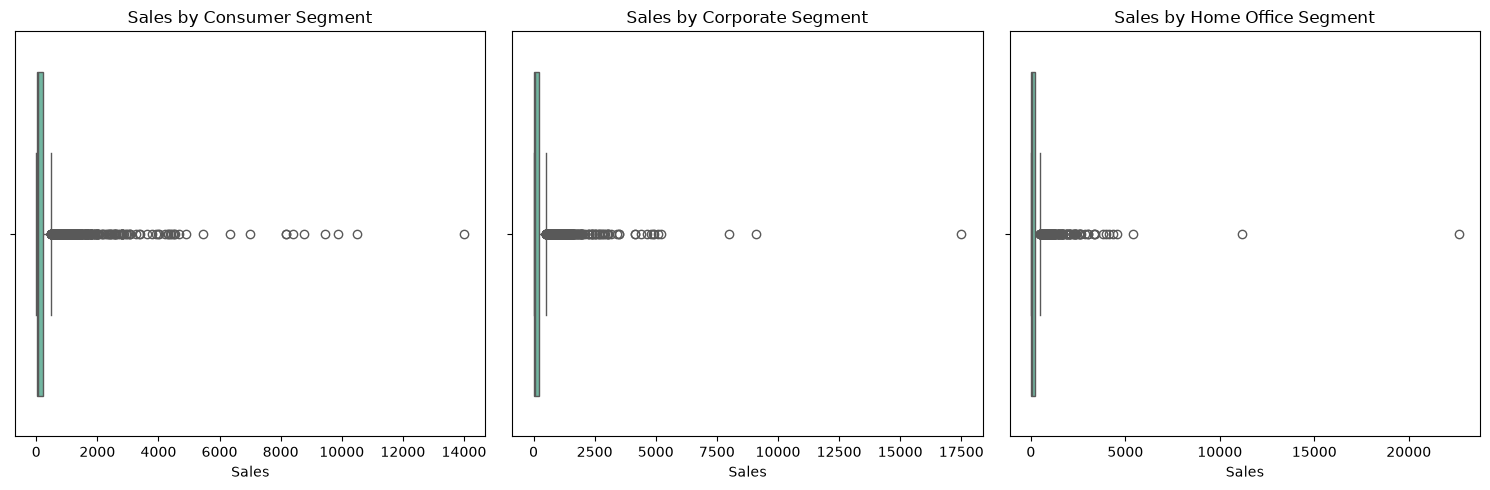

In [91]:
# Visual check for outliers in Sales segments using a boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=Consumer_Sales["Sales"], palette="Set2")
axes[0].set_title("Sales by Consumer Segment")

sns.boxplot(ax=axes[1], x=Corporate_Sales["Sales"], palette="Set2")
axes[1].set_title("Sales by Corporate Segment")

sns.boxplot(ax=axes[2], x=Home_Office_Sales["Sales"], palette="Set2")
axes[2].set_title("Sales by Home Office Segment")
plt.tight_layout()


**Quantifying outliers with the IQR rule.**
`find_outliers_iqr()` formalizes what the boxplots showed visually: any value
more than `1.5 × IQR` below Q1 or above Q3 is flagged as a statistical
outlier. The function returns the bounds used, the outlier count, and a
preview of the flagged rows — run separately for each segment so the bounds
are computed on each segment's own distribution rather than the combined
dataset. Note the function is intentionally **detection-only** here: it
reports outliers without dropping or capping them, keeping that decision
explicit and separate from the detection step.

In [ ]:
# IQR method: flag numeric outliers beyond 1.5x the interquartile range
def find_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    is_outlier = (data[column] < lower_bound) | (data[column] > upper_bound)
    outliers = data[is_outlier]
    n_outliers = is_outlier.sum()

    target_cols = [
        "Order_ID",
        "Customer_ID",
        "Sales",
        "Quantity",
        "Segment",
        "Profit",
    ]

    available_cols = [col for col in target_cols if col in data.columns]
    cols_to_show = available_cols if available_cols else data.columns

    return (
        str(data.shape[0]) + " rows",
        "lower bound: " + str(lower_bound),
        "upper bound: " + str(upper_bound),
        "number of outliers: " + str(n_outliers),
        outliers[cols_to_show].head(),
    )


print("=== Consumer Segment Outliers ===")
display(find_outliers_iqr(Consumer_Sales, "Sales"))

print("\n=== Corporate Segment Outliers ===")
display(find_outliers_iqr(Corporate_Sales, "Sales"))

print("\n=== Home Office Segment Outliers ===")
display(find_outliers_iqr(Home_Office_Sales, "Sales"))


=== Consumer Segment Outliers ===


('5189 rows',
 'lower bound: -266.03000000000003',
 'upper bound: 489.37800000000004',
 'number of outliers: 573',
         Sales  Quantity   Segment    Profit
 1    731.9400         3  Consumer  219.5820
 3    957.5775         5  Consumer -383.0310
 7    907.1520         6  Consumer   90.7152
 10  1706.1840         9  Consumer   85.3092
 11   911.4240         4  Consumer   68.3568)


=== Corporate Segment Outliers ===


('3019 rows',
 'lower bound: -274.96500000000003',
 'upper bound: 504.85100000000006',
 'number of outliers: 378',
         Sales  Quantity    Segment    Profit
 35   1097.544         7  Corporate  123.4737
 54   1029.950         5  Corporate  298.6855
 67   1113.024         8  Corporate  111.3024
 149  1951.840         8  Corporate  585.5520
 215  1188.000         9  Corporate -950.4000)


=== Home Office Segment Outliers ===


('1778 rows',
 'lower bound: -273.02925',
 'upper bound: 500.48875',
 'number of outliers: 218',
         Sales  Quantity      Segment    Profit
 38   532.3992         3  Home Office  -46.9764
 124  600.5580         3  Home Office   -8.5794
 182  503.9600         4  Home Office  131.0296
 189  899.1360         4  Home Office  112.3920
 192  626.3520         3  Home Office   46.9764)

**Extending the same check to `Quantity`.**
The same detect-before-you-touch approach is applied to `Quantity`: a boxplot
to see the spread visually, plus an explicit min/max range check, to confirm
whether `Quantity` shows the same kind of extreme-but-legitimate values seen
in `Sales` and `Profit`.

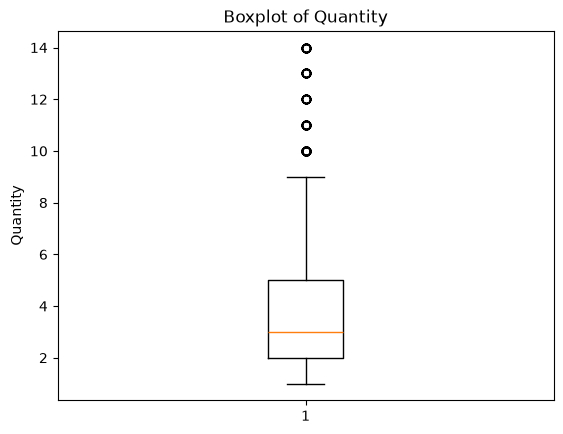

Quantity range: [1, 14]


In [103]:
# TODO 2: boxplot for Quantity
plt.boxplot(df_cleaned["Quantity"])
plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")
plt.show()

# TODO 3: range sanity check on Quantity (min/max)
print(f"Quantity range: [{df_cleaned['Quantity'].min()}, {df_cleaned['Quantity'].max()}]")

With missing values imputed, duplicates investigated, text standardized, and
outliers characterized (without being blindly removed), `df_cleaned` is now
in a trustworthy state. The last step is to persist it so downstream
notebooks (feature engineering, KPI generation, visualization) don't need to
repeat any of this work.

## 4. Export cleaned Data

**Exporting the cleaned dataset.**
`df_cleaned` is written out as `Sample-Superstore2019_cleaned.parquet`.
Parquet is used instead of CSV for this checkpoint because it preserves the
dtype work done in Section 2 (real `datetime64`, `category` columns) exactly
— a CSV re-read would silently turn all of that back into plain strings.

In [107]:
df_cleaned.to_parquet("Sample-Superstore2019_cleaned.parquet", index=False)